### tile-level: attention distribution using violin plot

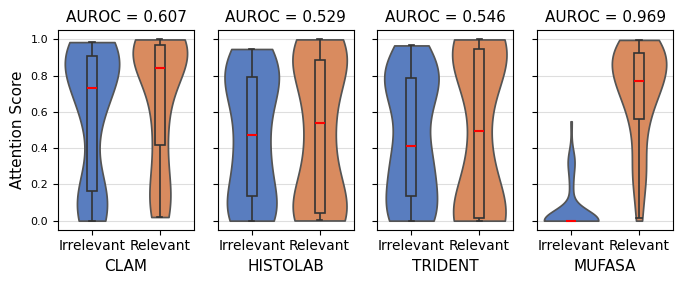


Plot saved to: /data_64T_3/Raja/MUFASA/2.Attention_Analysis/6.Results_and_plots/CAMELYON16/Output/CLAM_MB_MIL_Results_new/tile_level_attention_distribution.png

AUROC Results:
  CLAM: 0.6074
  HISTOLAB: 0.5289
  TRIDENT: 0.5455
  MUFASA: 0.9688


In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import os

def analyze_tile_level_attention_scores(input_path, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    # 1. Load data
    try:
        df = pd.read_csv(input_path)
    except FileNotFoundError:
        print(f"Error: File not found at {input_path}")
        return

    # 2. Check type column
    if 'type' not in df.columns:
        print("Error: 'type' column not found.")
        return

    # 3. Map labels
    if df['type'].dtype == 'object':
        label_mapping = {'relevant': 1, 'irrelevant': 0}
        df['binary_label'] = df['type'].map(label_mapping)
        df = df.dropna(subset=['binary_label'])
    else:
        df['binary_label'] = df['type']

    methods = ['CLAM', 'HISTOLAB', 'TRIDENT', 'MUFASA']

    # 4. Plot
    fig, axes = plt.subplots(1, 4, figsize=(7, 3), sharey=True)
    auroc_results = {}

    TICK_FONT_SIZE  = 10
    LABEL_FONT_SIZE = 11
    TITLE_FONT_SIZE = 11
    LINE_COLOR      = '#333333'
    MEDIAN_COLOR    = 'red'

    for i, method in enumerate(methods):
        col_name = f'{method}_attention'
        if col_name not in df.columns:
            print(f"Warning: column '{col_name}' not found, skipping.")
            continue

        ax = axes[i]

        # AUROC
        try:
            auroc = roc_auc_score(df['binary_label'], df[col_name])
            auroc_results[method] = auroc
        except ValueError:
            auroc = float('nan')

        # Violin plot
        sns.violinplot(
            x='type',           # ★ fixed: was 'label'
            y=col_name,
            hue='type',         # ★ fixed: was 'label'
            legend=False,
            data=df,
            ax=ax,
            inner=None,
            palette="muted",
            cut=0
        )

        # Box plot overlay
        sns.boxplot(
            x='type',           # ★ fixed: was 'label'
            y=col_name,
            data=df,
            ax=ax,
            width=0.15,
            showfliers=False,
            boxprops={'facecolor': 'None', 'edgecolor': LINE_COLOR, 'linewidth': 1.2},
            whiskerprops={'color': LINE_COLOR, 'linewidth': 1.2},
            capprops={'color': LINE_COLOR, 'linewidth': 1.2},
            medianprops={'color': MEDIAN_COLOR, 'linewidth': 1.5}
        )

        ax.set_title(f'AUROC = {auroc:.3f}', fontsize=TITLE_FONT_SIZE)
        ax.set_xlabel(method, fontsize=LABEL_FONT_SIZE, fontweight='normal')
        # ax.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)

        # --- ADD THIS HERE ---
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Irrelevant', 'Relevant'], fontsize=TICK_FONT_SIZE)
        # ---------------------

        if i == 0:
            ax.set_ylabel('Attention Score', fontsize=LABEL_FONT_SIZE)
        else:
            ax.set_ylabel('')

    plt.tight_layout()

    for ax in axes:
        ax.yaxis.grid(True, linestyle='-', which='major', color='lightgray', alpha=0.75)
        ax.set_axisbelow(True) # Ensure grid is behind the violins

    # 5. Save
    output_plot_path = os.path.join(output_dir, 'tile_level_attention_distribution.png')
    plt.savefig(output_plot_path, dpi=400, bbox_inches='tight')  # ★ was commented out
    plt.show()
    print(f"\nPlot saved to: {output_plot_path}")

    # 6. Print AUROC
    print("\nAUROC Results:")
    for method, score in auroc_results.items():
        print(f"  {method}: {score:.4f}")


# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
input_csv_path   = '/data_64T_3/Raja/MUFASA/2.Attention_Analysis/6.Results_and_plots/CAMELYON16/Output/CLAM_MB_MIL_Results/tile_level.csv'
output_directory = '/data_64T_3/Raja/MUFASA/2.Attention_Analysis/6.Results_and_plots/CAMELYON16/Output/CLAM_MB_MIL_Results_new/'

if __name__ == "__main__":
    analyze_tile_level_attention_scores(input_csv_path, output_directory)

### wsi/patch-level: Mean Difference in Attention Score (95% CI) and Paired Differences Distribution Wilcoxon 


--- Bootstrap Confidence Intervals (95%) ---
MUFASA vs CLAM: Mean Delta = 0.2629 [0.1457, 0.3919]
MUFASA vs HISTOLAB: Mean Delta = 0.3140 [0.1803, 0.4570]
MUFASA vs TRIDENT: Mean Delta = 0.2899 [0.1568, 0.4428]
Confidence interval plot saved to OUTPUT/wsi_level_confidence_interval_plot.png

--- Wilcoxon Signed-Rank Test ---
MUFASA vs CLAM: p-value = 9.7656e-04
MUFASA vs HISTOLAB: p-value = 9.7656e-04
MUFASA vs TRIDENT: p-value = 1.9531e-03
Wilcoxon boxplot saved to OUTPUT/wsi_level_wilcoxon_boxplot.png


/tmp/ipykernel_1984389/1058043725.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=baselines, patch_artist=True, showfliers=False,


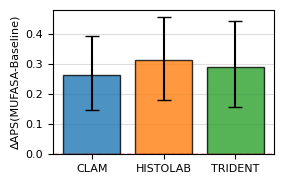

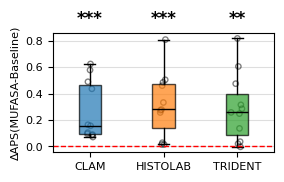

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import os
import argparse

# Set plot style
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 10,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'grid.color': 'lightgray',
    'grid.linestyle': '--',
    'axes.grid': False
})

def bootstrap_ci(data, n_boot=20000, alpha=0.05):
    """Calculates bootstrap confidence interval for the mean."""
    data = np.array(data)
    boot_means = np.random.choice(data, (n_boot, len(data)), replace=True).mean(axis=1)
    lower = np.percentile(boot_means, 100 * (alpha / 2))
    upper = np.percentile(boot_means, 100 * (1 - alpha / 2))
    return np.mean(data), lower, upper

def analyze_patch_wsi_level_attention_scores(csv_path, output_dir, level):
    # Load Data
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: File not found at {csv_path}")
        return

    # Define Baselines and MUFASA column
    baselines = ['CLAM', 'HISTOLAB', 'TRIDENT']
    mufasa_col = 'MUFASA_attention'
    
    # Check columns
    for b in baselines:
        if f'{b}_attention' not in df.columns:
            print(f"Error: Column {b}_attention not found.")
            return

    # Calculate Differences (Delta)
    deltas = {}
    for baseline in baselines:
        deltas[baseline] = df[mufasa_col] - df[f'{baseline}_attention']

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    # --- Plot 1: Confidence Interval Bar Plot ---
    fig, ax = plt.subplots(figsize=(3, 2))
    colors = ['#1F77B4', '#FF7F0E', '#2CA02C'] # Blue, Orange, Green
    
    means = []
    yerrs = [[], []] # lower, upper errors relative to mean
    
    print("\n--- Bootstrap Confidence Intervals (95%) ---")
    for i, baseline in enumerate(baselines):
        data = deltas[baseline]
        mean, lo, hi = bootstrap_ci(data)
        means.append(mean)
        yerrs[0].append(mean - lo)
        yerrs[1].append(hi - mean)
        print(f"MUFASA vs {baseline}: Mean Delta = {mean:.4f} [{lo:.4f}, {hi:.4f}]")

    # Bar Plot
    bars = ax.bar(baselines, means, yerr=yerrs, capsize=5, color=colors, alpha=0.8, edgecolor='black')
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_ylabel('ΔAPS(MUFASA-Baseline)')
    # ax.set_title('Mean Difference in Attention Score (95% CI)')

    ax.yaxis.grid(True, linestyle='-', color='lightgray', alpha=0.75)
    ax.set_axisbelow(True) # Puts the grid behind the boxplots/points
    
    plt.tight_layout()
    plot_path1 = os.path.join(output_dir, level+'_level_confidence_interval_plot.png')
    plt.savefig(plot_path1, dpi=400)
    print(f"Confidence interval plot saved to {plot_path1}")
    # plt.show() # Uncomment to show plot

    # --- Plot 2: Wilcoxon Signed-Rank Test Boxplot ---
    fig, ax = plt.subplots(figsize=(3, 2))
    
    # Prepare data for boxplot
    plot_data = [deltas[b] for b in baselines]
    
    # Create Boxplot
    bp = ax.boxplot(plot_data, labels=baselines, patch_artist=True, showfliers=False,
                    medianprops={'color':'black'}, boxprops={'linewidth': 1})

    # Color boxes
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Add Scatter Points
    for i, data in enumerate(plot_data):
        y = data
        x = np.random.normal(i + 1, 0.04, size=len(y)) # Jitter
        ax.scatter(x, y, alpha=0.5, s=15, facecolors='none', edgecolors='black')

    # Add Statistical Annotations
    y_max = max([d.max() for d in plot_data])
    y_range = y_max - min([d.min() for d in plot_data])
    
    print("\n--- Wilcoxon Signed-Rank Test ---")
    for i, baseline in enumerate(baselines):
        data = deltas[baseline]
        stat, p = wilcoxon(data)
        print(f"MUFASA vs {baseline}: p-value = {p:.4e}")
        
        # Determine significance stars
        if p < 0.001: sig = "***"
        elif p < 0.01: sig = "**"
        elif p < 0.05: sig = "*"
        else: sig = "ns"
        
        # Annotate plot
        ax.text(i + 1, y_max + 0.1 * y_range, sig, ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_ylabel('ΔAPS(MUFASA-Baseline)')
    # ax.set_title('Paired Differences Distribution')

    ax.yaxis.grid(True, linestyle='-', color='lightgray', alpha=0.75)
    ax.set_axisbelow(True) # Puts the grid behind the boxplots/points
    
    plt.tight_layout()
    plot_path2 = os.path.join(output_dir, level+'_level_wilcoxon_boxplot.png')
    plt.savefig(plot_path2, dpi=400)
    print(f"Wilcoxon boxplot saved to {plot_path2}")
    plt.show() # Uncomment to show plot

# --- Configuration ---
input_csv_path   = '/data_64T_3/Raja/MUFASA/2.Attention_Analysis/6.Results_and_plots/CAMELYON16/Results_new/Output/CLAM_MB_MIL_Results/wsi_level.csv'
output_directory = 'OUTPUT'

level = "wsi"  # WSI/ROI

if __name__ == "__main__":
    analyze_patch_wsi_level_attention_scores(input_csv_path, output_directory, level)

# if __name__ == "__main__":
#     parser = argparse.ArgumentParser(description="Analyze attention scores and generate plots.")
#     parser.add_argument("--input_file", type=str, required=True, help="Path to the input CSV file.")
#     parser.add_argument("--output_folder", type=str, required=True, help="Path to the output folder.")
#     args = parser.parse_args()

#     analyze_attention_scores(args.input_file, args.output_folder)

### wsi/patch-level: Mean Difference in Attention Score (95% CI) and Paired Differences Distribution T-test 


--- Bootstrap Confidence Intervals (95%) ---
MUFASA vs CLAM: Mean Delta = 0.2629 [0.1458, 0.3921]
MUFASA vs HISTOLAB: Mean Delta = 0.3140 [0.1813, 0.4580]
MUFASA vs TRIDENT: Mean Delta = 0.2899 [0.1558, 0.4403]
Confidence interval plot saved to OUTPUT/wsi_level_confidence_interval_plot.png

--- Paired t-test (one-sample t-test on deltas, H0: mean=0) ---
MUFASA vs CLAM: t=3.9723, p=2.6336e-03, n=11
MUFASA vs HISTOLAB: t=4.2632, p=1.6547e-03, n=11
MUFASA vs TRIDENT: t=3.7432, p=3.8262e-03, n=11
Paired t-test boxplot saved to OUTPUT/wsi_level_pairedttest_boxplot.png


/tmp/ipykernel_133325/3044649793.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=baselines, patch_artist=True,


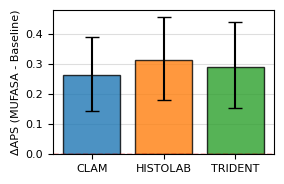

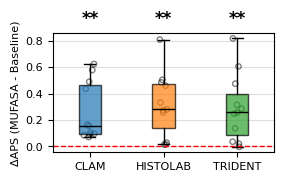

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp          # ★ replaced wilcoxon
import os

plt.rcParams.update({
    'font.size': 12, 'axes.titlesize': 10, 'axes.labelsize': 8,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8,
    'axes.facecolor': 'white', 'axes.edgecolor': 'black',
    'grid.color': 'lightgray', 'grid.linestyle': '--', 'axes.grid': False
})

def bootstrap_ci(data, n_boot=10000, alpha=0.05):
    data       = np.array(data)
    boot_means = np.random.choice(data, (n_boot, len(data)), replace=True).mean(axis=1)
    lower      = np.percentile(boot_means, 100 * (alpha / 2))
    upper      = np.percentile(boot_means, 100 * (1 - alpha / 2))
    return np.mean(data), lower, upper

def analyze_patch_wsi_level_attention_scores(csv_path, output_dir, level):
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: File not found at {csv_path}")
        return

    baselines  = ['CLAM', 'HISTOLAB', 'TRIDENT']
    mufasa_col = 'MUFASA_attention'

    for b in baselines:
        if f'{b}_attention' not in df.columns:
            print(f"Error: Column {b}_attention not found.")
            return

    deltas = {b: df[mufasa_col] - df[f'{b}_attention'] for b in baselines}

    os.makedirs(output_dir, exist_ok=True)

    # ── Plot 1: Bootstrap CI bar plot (unchanged) ─────────────────────────────
    fig, ax = plt.subplots(figsize=(3, 2))
    colors  = ['#1F77B4', '#FF7F0E', '#2CA02C']
    means   = []
    yerrs   = [[], []]

    print("\n--- Bootstrap Confidence Intervals (95%) ---")
    for i, baseline in enumerate(baselines):
        data = deltas[baseline]
        mean, lo, hi = bootstrap_ci(data)
        means.append(mean)
        yerrs[0].append(mean - lo)
        yerrs[1].append(hi - mean)
        print(f"MUFASA vs {baseline}: Mean Delta = {mean:.4f} [{lo:.4f}, {hi:.4f}]")

    ax.bar(baselines, means, yerr=yerrs, capsize=5,
           color=colors, alpha=0.8, edgecolor='black')
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_ylabel('ΔAPS (MUFASA - Baseline)')
    ax.yaxis.grid(True, linestyle='-', color='lightgray', alpha=0.75)
    ax.set_axisbelow(True) # Puts the grid behind the boxplots/points
    
    plt.tight_layout()
    plot_path1 = os.path.join(output_dir, level + '_level_confidence_interval_plot.png')
    #plt.savefig(plot_path1, dpi=400)
    print(f"Confidence interval plot saved to {plot_path1}")

    # ── Plot 2: Paired t-test boxplot ★ changed from Wilcoxon ─────────────────
    fig, ax  = plt.subplots(figsize=(3, 2))
    plot_data = [deltas[b] for b in baselines]

    bp = ax.boxplot(plot_data, labels=baselines, patch_artist=True,
                    showfliers=False,
                    medianprops={'color': 'black'},
                    boxprops={'linewidth': 1})

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    for i, data in enumerate(plot_data):
        x = np.random.normal(i + 1, 0.04, size=len(data))
        ax.scatter(x, data, alpha=0.5, s=15,
                   facecolors='none', edgecolors='black')

    y_max   = max([d.max() for d in plot_data])
    y_range = y_max - min([d.min() for d in plot_data])

    # ★ paired t-test: one-sample t-test on deltas vs 0
    print("\n--- Paired t-test (one-sample t-test on deltas, H0: mean=0) ---")
    for i, baseline in enumerate(baselines):
        data           = deltas[baseline].dropna()
        t_stat, p_val  = ttest_1samp(data, popmean=0)   # ★ was wilcoxon(data)
        print(f"MUFASA vs {baseline}: t={t_stat:.4f}, p={p_val:.4e}, n={len(data)}")

        sig = ("***" if p_val < 0.001 else
               "**"  if p_val < 0.01  else
               "*"   if p_val < 0.05  else "ns")

        ax.text(i + 1, y_max + 0.1 * y_range, sig,
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_ylabel('ΔAPS (MUFASA - Baseline)')
    ax.yaxis.grid(True, linestyle='-', color='lightgray', alpha=0.75)
    ax.set_axisbelow(True) # Puts the grid behind the boxplots/points
    
    plt.tight_layout()
    plot_path2 = os.path.join(output_dir, level + '_level_pairedttest_boxplot.png')  # ★ renamed
    #plt.savefig(plot_path2, dpi=400)
    print(f"Paired t-test boxplot saved to {plot_path2}")

# ─────────────────────────────────────────────
# CONFIG
# ───────────────────────────────────────────── 
input_csv_path   = '/data_64T_3/Raja/MUFASA/2.Attention_Analysis/6.Results_and_plots/CAMELYON16/Output/CLAM_MB_MIL_Results/wsi_level.csv'
output_directory = 'OUTPUT'
level            = "wsi"

if __name__ == "__main__":
    analyze_patch_wsi_level_attention_scores(input_csv_path, output_directory, level)

### Diagnostically relevant vs artifact retention rates

Plot saved to: /data_64T_3/Raja/MUFASA/2.Attention_Analysis/6.Results_and_plots/TCGA_LUSC/Output/CLAM_MB_MIL_Results_new/tumor_artifact_retention_rate.png

Summary Table (Percentage):
Method                    CLAM    HISTOLAB     MUFASA    TRIDENT
Label                                                           
Artifact                 100.0   93.939394   0.000000   3.030303
Diagnostically relevant  100.0  100.000000  96.226415  33.962264

Original label counts:
label
artifact    66
relevant    53
Name: count, dtype: int64

Combined label counts:
plot_label
Artifact                   66
Diagnostically relevant    53
Name: count, dtype: int64


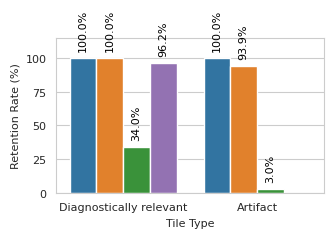

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def tissue_artifact_retention_rate(input_file, output_path):
    # 1. Read Data
    try:
        df = pd.read_csv(input_file)
    except Exception as e:
        print(f"Error reading file: {e}")
        return

    lbl_col = 'label'
    
    df['plot_label'] = df[lbl_col].apply(
        lambda x: 'Diagnostically relevant' if x == 'relevant' else
                  'Artifact' if x == 'artifact' else  
                  None
    ) 
    df = df.dropna(subset=['plot_label'])

    # 4. Define Categories & Methods
    categories = ['Diagnostically relevant', 'Artifact']
    methods    = ['CLAM', 'HISTOLAB', 'TRIDENT', 'MUFASA']   # ★ removed 'Total'

    results = []
    for cat in categories:
        cat_df      = df[df['plot_label'] == cat]
        total_count = len(cat_df)

        # ★ removed Total row — no longer appended here

        if total_count == 0:
            continue

        for method in methods:                               # ★ no more [1:] slice
            if method in df.columns:
                count      = len(cat_df[cat_df[method] == 1])
                percentage = (count / total_count) * 100
                results.append({
                    'Label':      cat,
                    'Method':     method,
                    'Count':      count,
                    'Percentage': percentage
                })

    # 5. Create DataFrame
    plot_df = pd.DataFrame(results)

    if plot_df.empty:
        print("No data found for the specified categories.")
        return

    # 6. Plot
    plt.figure(figsize=(3.5, 2.5))
    sns.set_style("whitegrid")

    method_colors = {
        'CLAM':     '#1f77b4',
        'HISTOLAB': '#ff7f0e',
        'TRIDENT':  '#2ca02c',
        'MUFASA':   '#9467bd'    # ★ removed 'Total' grey
    }

    ax = sns.barplot(
        data=plot_df,
        x='Label',
        y='Percentage',
        hue='Method',
        palette=method_colors,
        legend=False
    )

    plt.ylabel('Retention Rate (%)', fontsize=8)
    plt.xlabel('Tile Type', fontsize=8)
    plt.ylim(0, 115)
    plt.yticks(range(0, 101, 25), fontsize=8)
    plt.xticks(fontsize=8)

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=8, color='black', fontweight='normal',
                        rotation=90,
                        xytext=(0, 5), textcoords='offset points')

    plt.tight_layout()

    os.makedirs(output_path, exist_ok=True)
    save_file = os.path.join(output_path, 'tumor_artifact_retention_rate.png')
    plt.savefig(save_file, dpi=500, bbox_inches='tight')
    print(f"Plot saved to: {save_file}")

    # 7. Summary Table
    print("\nSummary Table (Percentage):")
    print(plot_df.pivot(index='Label', columns='Method',
                        values='Percentage').fillna(0))

    print("\nOriginal label counts:")
    print(df[lbl_col].value_counts())
    print("\nCombined label counts:")
    print(df['plot_label'].value_counts())

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
input_csv_path   = '/data_64T_3/Raja/MUFASA/2.Attention_Analysis/6.Results_and_plots/TCGA_LUSC/Output/CLAM_MB_MIL_Results/tile_level.csv'
output_directory = '/data_64T_3/Raja/MUFASA/2.Attention_Analysis/6.Results_and_plots/TCGA_LUSC/Output/CLAM_MB_MIL_Results_new'
tissue_artifact_retention_rate(input_csv_path, output_directory)

In [23]:
import pandas as pd

# Load your data
input_csv_path = '/data_64T_3/Raja/MUFASA/2.Attention_Analysis/6.Results_and_plots/TCGA_LUSC/Output/CLAM_MB_MIL_Results/tile_level.csv'
df = pd.read_csv(input_csv_path)

# Count occurrences in the 'label' column
label_counts = df['label'].value_counts()

print("Sample counts per label:")
print(label_counts)

Sample counts per label:
label
artifact     66
relevant     53
non-tumor    25
Name: count, dtype: int64


In [24]:
import pandas as pd

# Load your data
input_csv_path = '/data_64T_3/Raja/MUFASA/2.Attention_Analysis/6.Results_and_plots/CAMELYON16/Output/CLAM_MB_MIL_Results/tile_level.csv'
df = pd.read_csv(input_csv_path)

# Count occurrences in the 'label' column
label_counts = df['label'].value_counts()

print("Sample counts per label:")
print(label_counts)

Sample counts per label:
label
relevant     60
non-tumor    43
artifact     13
Name: count, dtype: int64
